# Embedding Prior Knowledge

The core design philosophy of SINDy is to produce interpretable governing equations that define the dynamics of a system. However, if certain dynamics are known, we may also embed known physics into the model learning process. In this tutorial, we seek to
1. Incorporate custom functions that are known to exist within the equation structure.
2. Constrain the sparse regression process using a constrained optimization search with Lagrange multipliers.
3. Selecting the appropriate model using prior sparsity knowledge.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysindy as ps
import warnings
from IPython.display import display, Math

from sindy.odes import lorenz
from sindy.ivp_solvers import rk4
from sindy.library import poly_lib, trig_lib, combine_libs
from sindy.optimizer import stlsq, stcls, stridge
from sindy.metrics import rel_fro_err
from sindy.plot_utils import init_plt_format
from sindy.utils import set_seed, print_latex_eqn
from sindy.plot_utils import visualize_ode_2d

warnings.filterwarnings('ignore', category=RuntimeWarning)
init_plt_format()
set_seed(0)

# Incorporating Custom Functions

If we are aware that certain functions must be included in the governing equation, then we may include it separately within the library. For instance, taking an example from [(Strogatz, 2018)](https://www.taylorfrancis.com/books/mono/10.1201/9780429399640/nonlinear-dynamics-chaos-student-solutions-manual-steven-strogatz), the dynamics of two bar magnets that are free to rotate around a common pin joint are defined by

$$
\begin{aligned}
\dot{\theta}_1 &= K \text{sin}(\theta_1 - \theta_2) - \text{sin}(\theta_1) \\
\dot{\theta}_2 &= K \text{sin}(\theta_2 - \theta_1) - \text{sin}(\theta_2).
\end{aligned}
$$

An example trajectory is shown below:

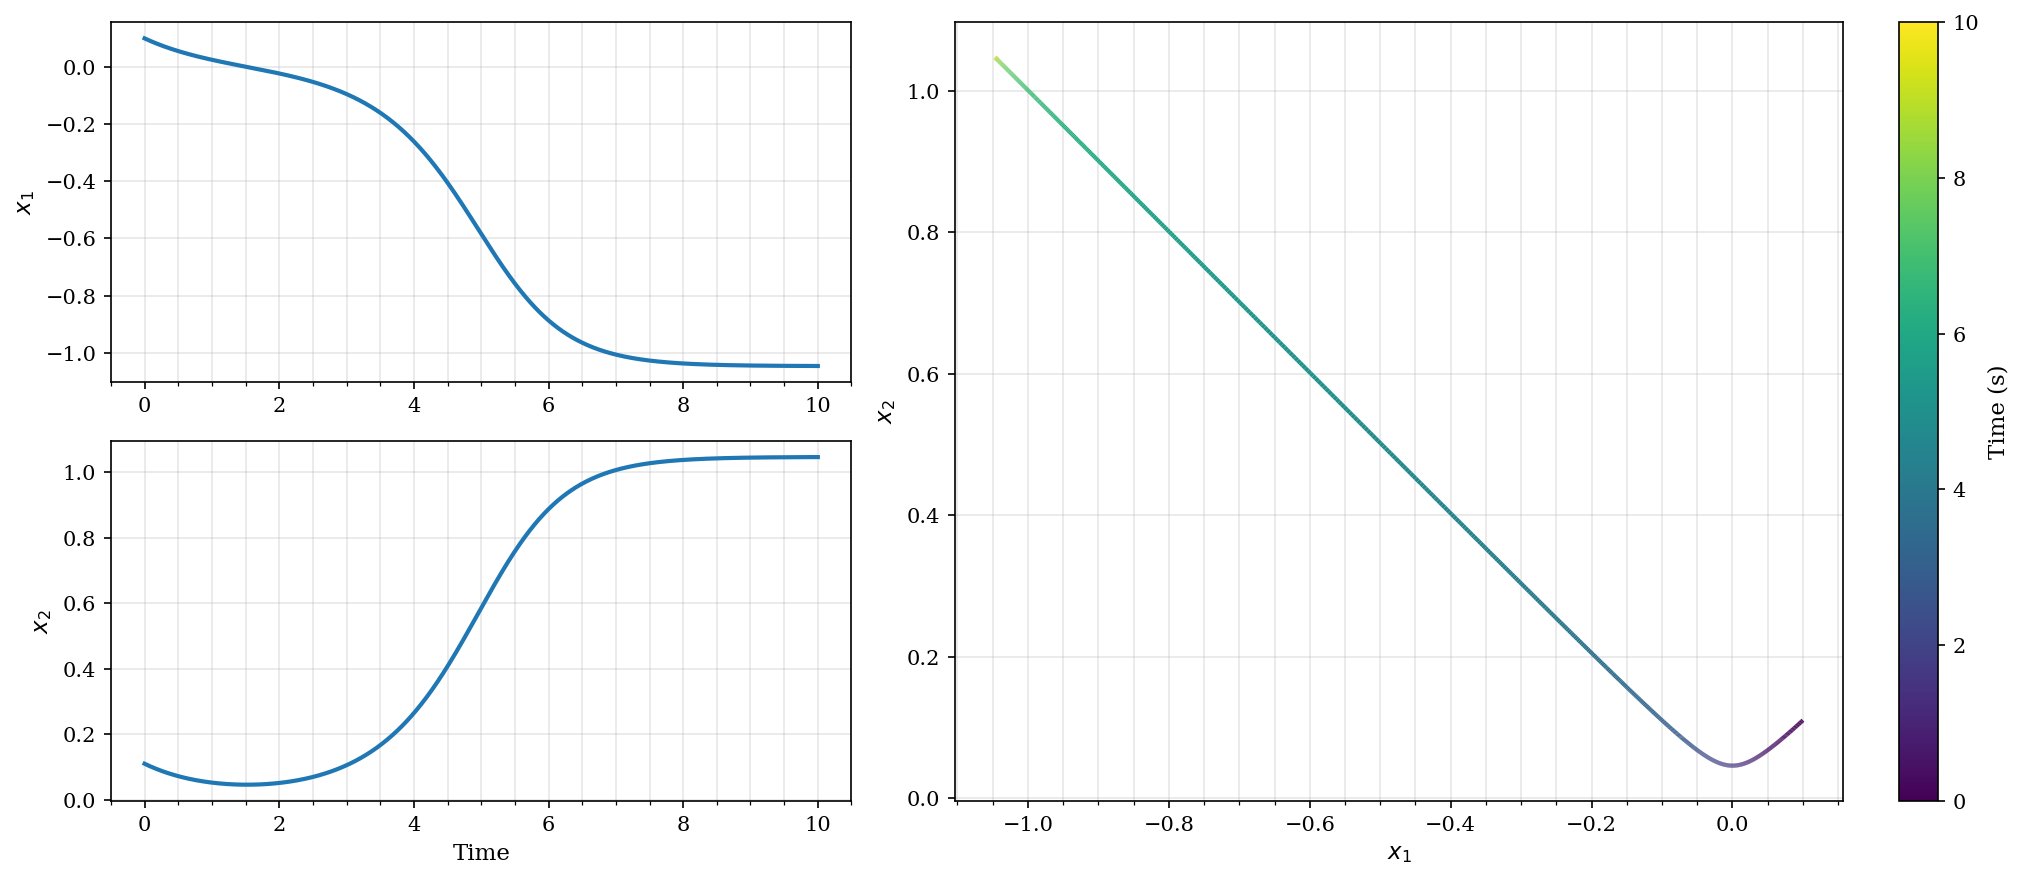

In [2]:
def rotating_magnets(t: float, x: np.ndarray, K: float = 1.0) -> np.ndarray:

    return np.array([
        K * np.sin(x[0] - x[1]) - np.sin(x[0]),
        K * np.sin(x[1] - x[0]) - np.sin(x[1])
    ])

# Solve the ODE
tFinal = 10
dt = 0.01
x0 = np.array([0.1, 0.11])
t, x = rk4(rotating_magnets, tFinal, x0, dt)

# Visualize the trajectory
visualize_ode_2d(x, t)

We will not be able to learn this using a Fourier library that only contains functions of the form $\sin(nx)$ and $\cos(nx)$. In this case, we should specify custom trigonometric functions that uses the difference of two state variables.

In [3]:
# Define a trigonometric library with a single frequency
lib, lib_names = trig_lib(x, 1)

# Define a custom library
custom_lib = np.hstack([np.sin(x[:,0] - x[:,1]).reshape(-1,1)])
custom_lib_names = ['sin(x_1 - x_2)']

# Combine the two libraries
combined_lib, combined_lib_names = combine_libs(
    [lib, custom_lib],
    [lib_names, custom_lib_names]
)

# Print out functions within the combined library
display(Math(', '.join(combined_lib_names)))

<IPython.core.display.Math object>

Now, we may learn a model using this candidate function library.

In [4]:
# Numerically differentiate and fit the model
xdot = ps.FiniteDifference(4)._differentiate(x, t)
xi = stlsq(combined_lib, xdot)

display(Math(print_latex_eqn(xi, ['x_1', 'x_2'], combined_lib_names)))

<IPython.core.display.Math object>

In PySINDy, custom functions may be defined using `ps.CustomLibrary` and PySINDy libraries can be added together with a `+` operator or `ps.ConcatLibrary`.

# Constrained-based Regression

Given the prior knowledge of a system, we may wish to bake in known physics, such as energy preserving non-linearities or enforcement of symmetry, through the use of equality and inequality constraints. There are several possible methods such as PySINDy's `ConstrainedSR3` and `TrappingSR3`. Let us formulate a sequentially thresholded constrained least squares (STCLS) algorithm similar to [(Louiseau and Brunton, 2018)](https://www.cambridge.org/core/journals/journal-of-fluid-mechanics/article/constrained-sparse-galerkin-regression/0E18A4A55FF5AC1401D236C0E4D1CAAE) which seeks to solve the iterative constrained regression problem of


$$
\begin{aligned}
    \min_{\Xi} & \space || \Theta(X) \Xi - \dot{X} ||^2 + \lambda || \Xi ||_0 + \gamma || \Xi ||^2_2 \\
    \text{s.t.} & \space C \Xi(:) = d
\end{aligned}
$$

The constrained regression problem can be reformulated as an unconstrained regression problem using Lagrange multipliers such that

$$
\begin{bmatrix}
    H & \frac{1}{2} C^T \\
    C & 0
\end{bmatrix}
\begin{bmatrix}
    \Xi(:) \\
    z
\end{bmatrix}
=
\begin{bmatrix}
    \hat{\Theta}^T \dot{X}(:) \\
    d
\end{bmatrix}
$$

where the Hessian matrix $H = \hat{\Theta}^T \hat{\Theta} + \gamma I$ and $\hat{\Theta}$ is defined as $I \otimes \Theta$. $\otimes$ denote a Kronecker product. $(\bullet) (:)$ denotes a flattened matrix such that

$$
\Xi = \begin{bmatrix}
    | & & | \\
    \xi_1 & \dots & \xi_n \\
    | & & |
\end{bmatrix}
\Rightarrow
\Xi (:) = \begin{bmatrix}
    | \\
    \xi_1 \\
    | \\
    \vdots \\
    | \\
    \xi_n \\
    |
\end{bmatrix}
$$

In order to define the $d$ number of constraints for $\Xi(:) \in \mathbb{R}^{ln}$, we must specify two constraint matrices $C \in \mathbb{R}^{d \times ln}$ and $d \in \mathbb{R}^{d}$. Each row within the LHS constraint matrix $C$ corresponds to a single constraint equation where each element on the row specifies the multiplier of each coefficient in $\xi$ within the constraint. For instance, if we wish to apply an anti-symmetry constraint for the Lorenz system where $x = -y$ for $\dot{x}$ and enforce a known coefficient $28x$ for $\dot{y}$, we should begin with identifying the correct coefficient indices by inspecting the candidate functions present in $\Theta$.

In [5]:
# Set library settings
poly_order = 5
include_bias = False

# Compute the Lorenz system
t, x = rk4(lorenz, 10, np.array([1, 1, 1]))
state_names = ['x', 'y', 'z']
lib, lib_names = poly_lib(x, poly_order, include_bias, state_names)

df_lib = pd.DataFrame(lib_names, columns=['Candidate function'])
display(df_lib)

,Candidate function
0,x
1,y
2,z
3,x^2
4,x y
5,x z
6,y^2
7,y z
8,z^2
9,x^3


By inspecting the above, we have $l=55$ candidate functions for our $n=3$ state system. Therefore, the constraint matrices must be sized $C \in \mathbb{R}^{2 \times 165}$ and $d \in \mathbb{R}^{2}$ when applying $d=2$ number of constraints. For the first constraint, the terms we are interested in are located at the 1st and 2nd indices of the library. Hence, we will specify $c_{1,1} = c_{1,2} = 1$ and $d_{1} = 0$ to constrain

$$ \Xi_{1,1} + \Xi_{2,1} = (\Xi(:))_{1} + (\Xi(:))_{2} = 0 $$

which corresponds to $x + y = 0$ for equation defining $\dot{x}$. Similarly, for our second constraint, we are interested in the first candidate function but for $\dot{y}$. Hence, we will specify $c_{2,56} = 1$ and $d_2 = 28$ to constrain

$$ \Xi_{1,2} = (\Xi(:))_{56} = 28 $$

In [6]:
# Initialise the constraint matrices
constraint_lhs = np.zeros((2, lib.shape[1]*x.shape[1]))
constraint_rhs = np.zeros((2,))

# Define first constraint
constraint_lhs[0, 0] = 1
constraint_lhs[0, 1] = 1
# Note that the RHS of the first constraint is already initialized as 0

# Define second constraint
constraint_lhs[1, 55] = 1
constraint_rhs[1] = 28

Now let us apply the constraint matrix in the optimization process.

In [7]:
# Compute the time derivative
xdot = ps.FiniteDifference(4)._differentiate(x, t)

# Fit a constrained SINDy model
xi = stcls(
    lib, xdot,
    constraint_lhs=constraint_lhs, constraint_rhs=constraint_rhs
)

display(Math(print_latex_eqn(xi, state_names, lib_names)))

<IPython.core.display.Math object>

Applying constraints not only allow us to bake in prior knowledge, but also reduces the total number of coefficients that must be discovered. This leads to a reduction in total data requirement. The effect on data quantity is shown below:

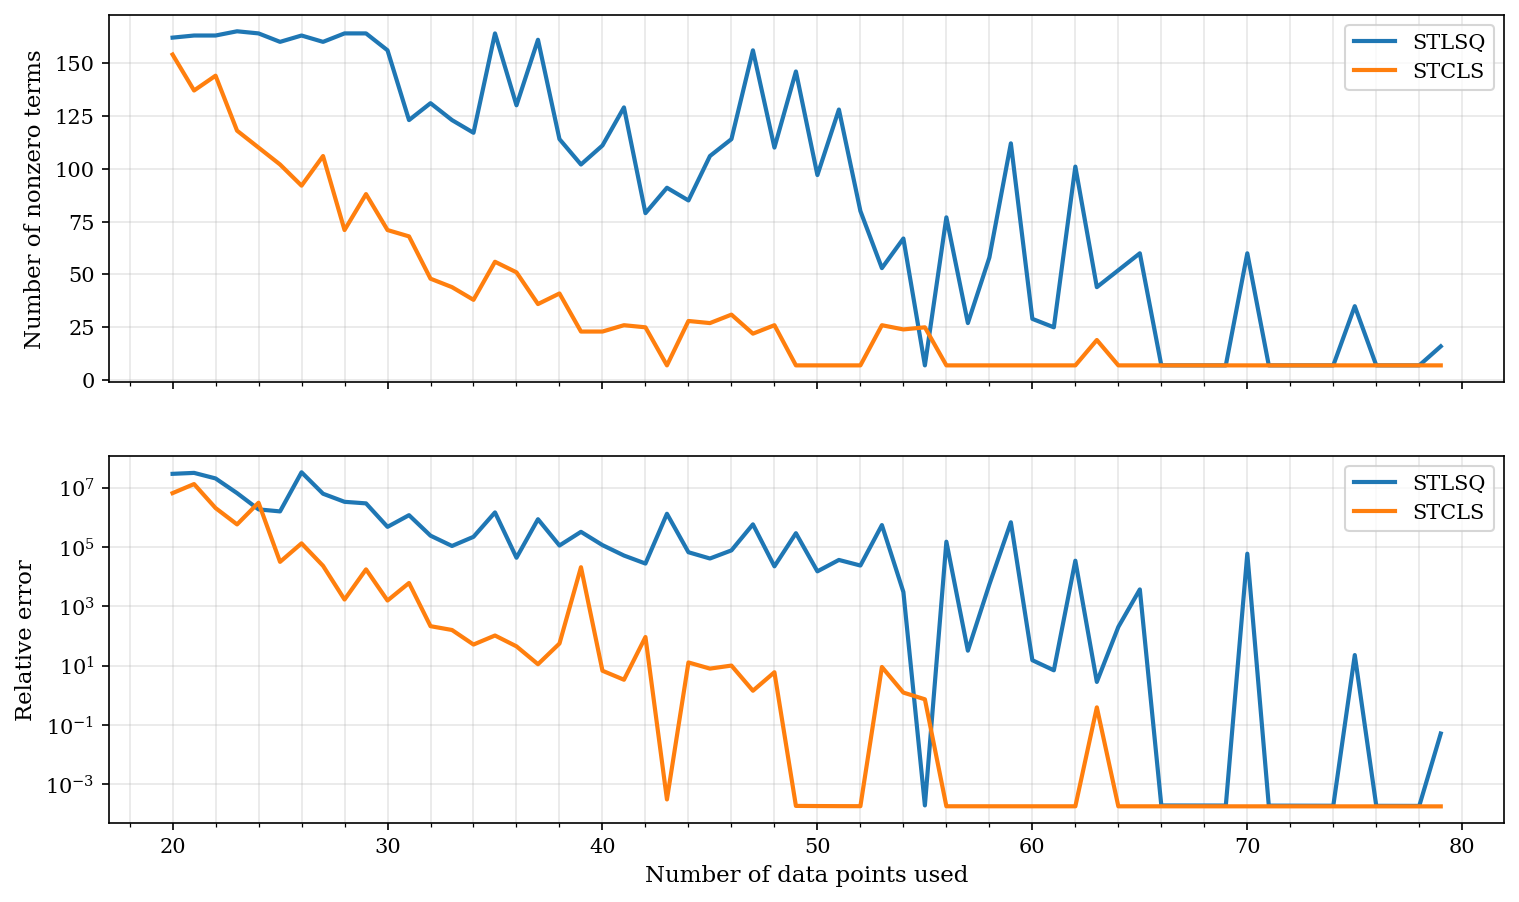

In [8]:
# Define the number of data points to sweep
data_pts = np.arange(20, 80)

# Initialise metrics
stlsq_nonzero = list()
stcls_nonzero = list()
stlsq_err = list()
stcls_err = list()

# Loop through different quantities of data
for cutoff_idx in data_pts:

    # Fit data using STLSQ
    xi = stlsq(lib[:cutoff_idx,:], xdot[:cutoff_idx,:])
    stlsq_nonzero.append(np.count_nonzero(xi))
    stlsq_err.append(rel_fro_err(
        lib @ xi,
        xdot
    ))
    
    # Fit data using STCLS
    xi = stcls(
        lib[:cutoff_idx,:], xdot[:cutoff_idx,:],
        constraint_lhs=constraint_lhs,
        constraint_rhs=constraint_rhs
    )
    stcls_nonzero.append(np.count_nonzero(xi))
    stcls_err.append(rel_fro_err(
        lib @ xi,
        xdot
    ))

# Plot the results
fig, axs = plt.subplots(2, 1, figsize=(12,7), sharex=True)

axs[0].plot(data_pts, stlsq_nonzero, label='STLSQ')
axs[0].plot(data_pts, stcls_nonzero, label='STCLS')
axs[0].set_ylabel('Number of nonzero terms')
axs[0].legend()

axs[1].plot(data_pts, stlsq_err, label='STLSQ')
axs[1].plot(data_pts, stcls_err, label='STCLS')
axs[1].set_yscale('log')
axs[1].set_ylabel('Relative error')
axs[1].set_xlabel('Number of data points used')
axs[1].legend();

As shown, we require fewer data points to recover the correct model by defining two equality constraints.

Note that the constraint matrix is constructed in the same manner as required by PySINDy's `ConstrainedSR3` and `TrappingSR3`.

# Model Selection via Stability Selection

If we have prior knowledge on the level of expected sparsity, we may conduct a hyperparameter sweep for $\lambda$ to determine the appropriate parameter to use. [(Maddu et al, 2022)](https://royalsocietypublishing.org/rspa/article/478/2262/20210916/54488/Stability-selection-enables-robust-learning-of) proposes the use of statistical stability selection during the sweep process to identify terms that are statistically stable, in the sense that they persist in the learned model when learning from subsets of data. It is done by fitting $B$ number of models using $B$ subsets of data. A $\lambda$ dependent importance measure $\hat{\Pi}^\lambda_k$ can be computed for each $k\text{th}$ coefficient in $\Xi$ defined by its inclusion probability in all models such that

$$ \hat{\Pi}^\lambda_k \approx \frac{1}{B} \sum^B_{i=1} 1\!\!1 (\Xi_k \ne 0) $$

Each subset of data sized $m/2$ is randomly sampled from $m$ data points. A reference value for $\hat{\Pi}^\lambda_k = 0.8$ is recommended to be used as the threshold for stable support. 

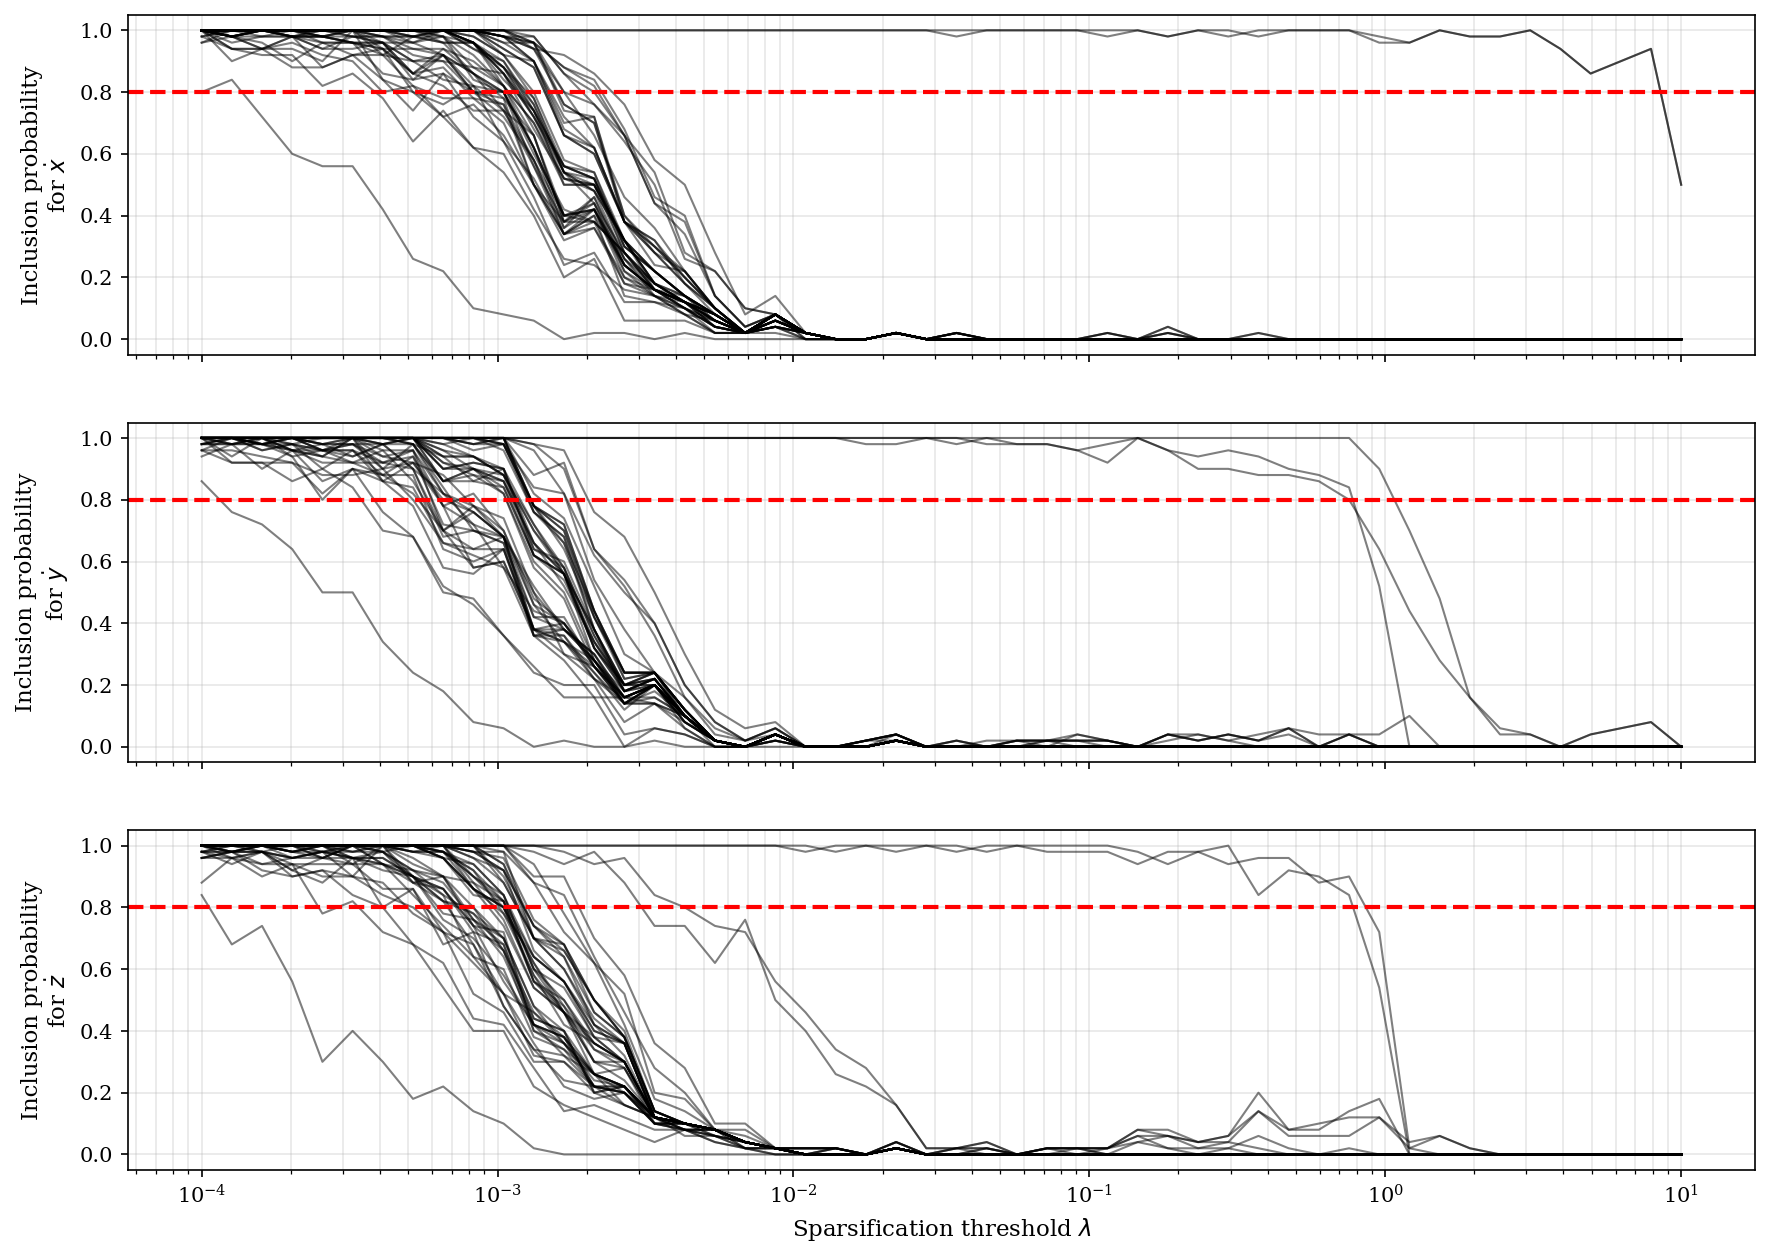

In [9]:
# Define time step and simulation time
dt: float = 1e-2
tFinal: float = 10

# Define the level of noise to add
epsilon: float = 1e-2

# Define the number of subsets to create
B: int = 50

# Define the lambda values to sweep
lambdas: np.ndarray = np.logspace(-4,1,50)
j: int = lambdas.shape[0]

# Compute trajectory
x0: np.ndarray = np.random.uniform(-10, 10, (3,))
t, x = rk4(lorenz, tFinal, x0, dt)
x += epsilon * np.random.normal(0,1,x.shape)
xdot = ps.FiniteDifference(4)._differentiate(x,t)

# Get dimensional information of the dataset
m: int = x.shape[0]
n: int = x.shape[1]

# Initialise the library to obtain size information of the library
l: int = (poly_lib(x, poly_order, include_bias)[0]).shape[1]

# Initialise coefficient inclusion counter for each lambda
term_counter: list[np.ndarray] = list()
 
# Sweep through all thresholds
for lam_idx, lam in enumerate(lambdas):

    term_counter.append(np.zeros((l,n)))

    # Loop through all subsets of data
    for b_idx in range(B):

        # Sample a subset sized m/2
        sample_idx = np.random.choice(range(m), (int(m/2),))

        # Fit a new model
        theta = poly_lib(x[sample_idx,:], poly_order, include_bias)[0]
        xi = stlsq(theta, xdot[sample_idx,:], lam)

        # Add active terms to counter
        term_counter[-1] += xi != 0.

# Compute importance measure (inclusion probability)
im: np.ndarray = np.array([counter/B for counter in term_counter])

# Visualize importance measure
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(14,10))

for n_idx in range(n):
    axs[n_idx].plot(lambdas, im[:,:,n_idx], 'k', linewidth=1, alpha=0.5)
    axs[n_idx].axhline(0.8, linestyle='--', color='red')
    axs[n_idx].set_xscale('log')
    axs[n_idx].set_ylabel(
        'Inclusion probability\n' + rf'for $\dot{{{state_names[n_idx]}}}$'
    )

axs[-1].set_xlabel(r'Sparsification threshold $\lambda$');

One may make an informed decision on the hyperparameter to select based on the expected level of sparsification. Though in cases such as this one where the key dynamics are captured, there is typically a distinct tapering off of irrelevant functions past a set threshold level. A hyperparameter may be selected based purely on where this tapering occurs, as coefficients from noisy or irrelevant components would converge to zero sooner than stable components. The threshold should be selected such that it is placed in between the decay of noisy components and stable components.

<IPython.core.display.Math object>

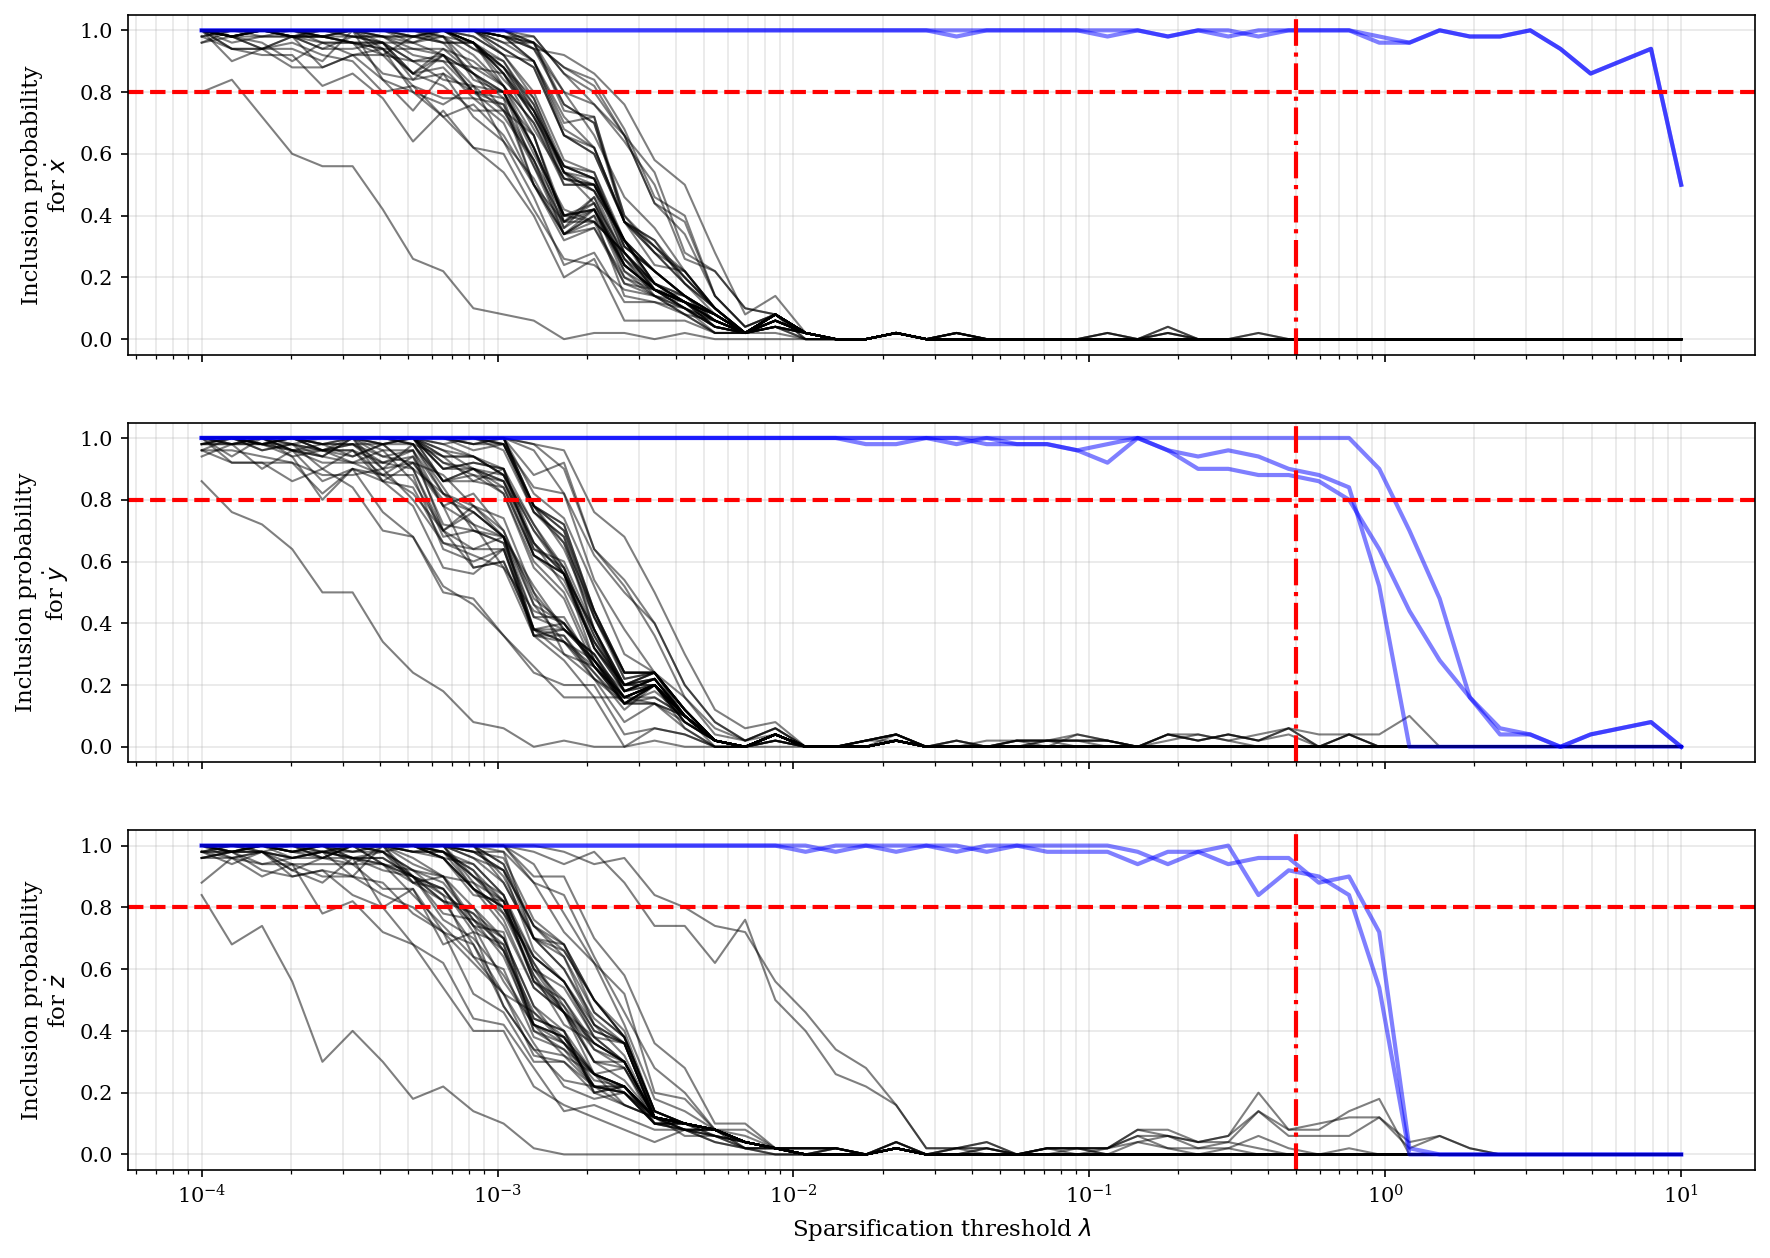

In [10]:
# Select a lambda based on the above plots
lam: float = 0.5

# Obtain final model
theta = poly_lib(x, poly_order, include_bias)[0]
xi = stlsq(theta, xdot, lam)

# Print final model
display(Math(print_latex_eqn(xi, state_names, lib_names)))

# Revisualize the plot but highlighting the active terms that was selected
# the chosen lambda value
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(14,10))

for n_idx in range(n):
    axs[n_idx].plot(
        lambdas, im[:,xi[:, n_idx]==0, n_idx],
        'k', linewidth=1, alpha=0.5, label='Inactive terms'
    )
    axs[n_idx].plot(
        lambdas, im[:,xi[:, n_idx]!=0, n_idx],
        'b', alpha=0.5, label='Active terms'
    )
    axs[n_idx].axvline(lam, linestyle='-.', color='red')
    axs[n_idx].axhline(0.8, linestyle='--', color='red')
    axs[n_idx].set_xscale('log')
    axs[n_idx].set_ylabel(
        'Inclusion probability\n' + rf'for $\dot{{{state_names[n_idx]}}}$'
    )

axs[-1].set_xlabel(r'Sparsification threshold $\lambda$');

There are other methods to select the appropriate sparsification level such as Akaike information criteria (AIC) as proposed by [(Mangan et al, 2017)](https://royalsocietypublishing.org/rspa/article/473/2204/20170009/57451/Model-selection-for-dynamical-systems-via-sparse), or cross-validation common in machine learning practices. However, stability selection provides the most intuitive method to select such parameter and will be the primary method of choice for selecting models in this tutorial series.